# 🎙️ Voice Model — Dysarthria / Syncope Risk Detection
**Dataset:** TORGO — 8000 audio samples (Control vs Dysarthric speakers)  
**Architecture:** CNN on Mel-Spectrograms  
**Goal:** Binary classification — Normal vs Dysarthric speech  
**Language-agnostic:** Works with any language / accent  
**GPU:** T4 or P100 on Kaggle


## 1️⃣ Install & Imports

In [2]:
!pip install librosa soundfile audiomentations -q

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import librosa
import librosa.display
import soundfile as sf
from audiomentations import Compose, AddGaussianNoise, TimeStretch, PitchShift, Shift

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
from torchvision import models

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cpu')
print(f'Using device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 15.2 MB/s eta 0:00:00
Using device: cpu
GPU: Tesla T4


## 2️⃣ Dataset Discovery — Build File Index

In [3]:
# ─────────────────────────────────────────────
# TORGO Dataset Path
# ─────────────────────────────────────────────
DATA_ROOT = Path('/kaggle/input/datasets/pranaykoppula/torgo-audio')

# Folder name → label mapping
# F_Con, M_Con = Control (Normal)   → label 0
# F_Dys, M_Dys = Dysarthric         → label 1
LABEL_MAP = {
    'F_Con': 0,
    'M_Con': 0,
    'F_Dys': 1,
    'M_Dys': 1,
}

records = []
for folder, label in LABEL_MAP.items():
    folder_path = DATA_ROOT / folder
    if not folder_path.exists():
        print(f'⚠️  Folder not found: {folder_path}')
        continue
    # Walk all subdirectories
    for audio_file in folder_path.rglob('*.wav'):
        records.append({'path': str(audio_file), 'label': label, 'group': folder})

df = pd.DataFrame(records)
print(f'Total audio files found: {len(df)}')
print(df['group'].value_counts())
print(df['label'].value_counts())
df.head()

Total audio files found: 17635
group
M_Con    6778
F_Con    4678
M_Dys    3788
F_Dys    2391
Name: count, dtype: int64
label
0    11456
1     6179
Name: count, dtype: int64


,path,label,group
0,/kaggle/input/datasets/pranaykoppula/torgo-aud...,0,F_Con
1,/kaggle/input/datasets/pranaykoppula/torgo-aud...,0,F_Con
2,/kaggle/input/datasets/pranaykoppula/torgo-aud...,0,F_Con
3,/kaggle/input/datasets/pranaykoppula/torgo-aud...,0,F_Con
4,/kaggle/input/datasets/pranaykoppula/torgo-aud...,0,F_Con


## 3️⃣ Audio Config & Feature Extraction

Waveform shape: (48000,)
Mel-spec shape: (128, 128)


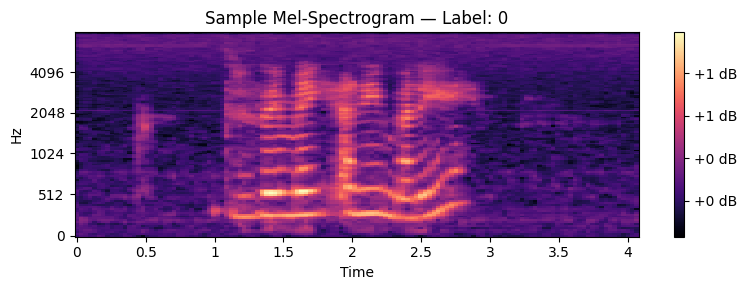

In [4]:
# ─────────────────────────────────────────────
# Audio hyperparameters
# ─────────────────────────────────────────────
SR         = 16000    # Target sample rate (Hz)
DURATION   = 3.0      # Fixed clip duration (seconds)
N_SAMPLES  = int(SR * DURATION)

N_MELS     = 128      # Number of Mel filter banks
N_FFT      = 1024     # FFT window size
HOP_LENGTH = 512      # Hop length
FMAX       = 8000     # Max frequency

IMG_H, IMG_W = 128, 128  # Spectrogram image size fed to CNN

def load_audio(path, sr=SR, duration=DURATION):
    """Load audio, resample, pad/trim to fixed length."""
    try:
        y, _ = librosa.load(path, sr=sr, mono=True)
    except Exception:
        return np.zeros(N_SAMPLES, dtype=np.float32)
    
    # Pad or trim
    if len(y) < N_SAMPLES:
        y = np.pad(y, (0, N_SAMPLES - len(y)))
    else:
        y = y[:N_SAMPLES]
    return y.astype(np.float32)

def audio_to_melspec(y, sr=SR):
    """Convert waveform to log Mel-Spectrogram (128x128)."""
    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=N_MELS,
        n_fft=N_FFT, hop_length=HOP_LENGTH, fmax=FMAX
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    # Normalize to [0, 1]
    mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-6)
    # Resize to IMG_H x IMG_W
    mel_db = np.array([
        np.interp(
            np.linspace(0, mel_db.shape[1]-1, IMG_W),
            np.arange(mel_db.shape[1]),
            row
        ) for row in mel_db
    ])
    if mel_db.shape[0] != IMG_H:
        from PIL import Image
        import torchvision.transforms.functional as F
        mel_db = np.array(Image.fromarray((mel_db * 255).astype(np.uint8)).resize((IMG_W, IMG_H))) / 255.0
    return mel_db.astype(np.float32)  # shape: (128, 128)

# ── Quick sanity check ──
sample_y = load_audio(df['path'].iloc[0])
sample_mel = audio_to_melspec(sample_y)
print(f'Waveform shape: {sample_y.shape}')
print(f'Mel-spec shape: {sample_mel.shape}')

plt.figure(figsize=(8, 3))
librosa.display.specshow(sample_mel, sr=SR, hop_length=HOP_LENGTH, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title(f'Sample Mel-Spectrogram — Label: {df["label"].iloc[0]}')
plt.tight_layout()
plt.show()

## 4️⃣ Data Augmentation (Language/Accent Agnostic)

In [5]:
# Augmentation pipeline — applied only during TRAINING
# These transforms make the model accent/language agnostic
augment = Compose([
    AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.015, p=0.4),
    TimeStretch(min_rate=0.85, max_rate=1.15, p=0.4),
    PitchShift(min_semitones=-3, max_semitones=3, p=0.4),
    Shift(min_shift=-0.2, max_shift=0.2, p=0.3),
])

## 5️⃣ PyTorch Dataset

In [6]:
class TORGODataset(Dataset):
    def __init__(self, df, augment=None, train=True):
        self.df = df.reset_index(drop=True)
        self.augment = augment
        self.train = train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        y = load_audio(row['path'])

        # Apply augmentation only during training
        if self.train and self.augment and random.random() < 0.6:
            y = self.augment(samples=y, sample_rate=SR)
            # Re-pad/trim after augmentation
            if len(y) < N_SAMPLES:
                y = np.pad(y, (0, N_SAMPLES - len(y)))
            else:
                y = y[:N_SAMPLES]

        mel = audio_to_melspec(y)  # (128, 128)
        # Stack to 3 channels (RGB-like) for pretrained CNN
        mel_tensor = torch.tensor(mel).unsqueeze(0).repeat(3, 1, 1)  # (3, 128, 128)

        label = torch.tensor(row['label'], dtype=torch.long)
        return mel_tensor, label

## 6️⃣ Train/Val/Test Split + Dataloaders

In [7]:
# Stratified split: 70% train, 15% val, 15% test
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['label'], random_state=SEED)
val_df, test_df   = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=SEED)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')
print('Train label dist:\n', train_df['label'].value_counts())

# ── Weighted sampler to handle class imbalance ──
label_counts = train_df['label'].value_counts().to_dict()
weights = train_df['label'].map(lambda x: 1.0 / label_counts[x]).values
sampler = WeightedRandomSampler(weights=torch.FloatTensor(weights), num_samples=len(train_df), replacement=True)

BATCH_SIZE = 32
NUM_WORKERS = 2

train_ds = TORGODataset(train_df, augment=augment, train=True)
val_ds   = TORGODataset(val_df, augment=None, train=False)
test_ds  = TORGODataset(test_df, augment=None, train=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Train: 12344 | Val: 2645 | Test: 2646
Train label dist:
 label
0    8019
1    4325
Name: count, dtype: int64
Train batches: 386 | Val batches: 83


## 7️⃣ Model Architecture — EfficientNet-B0 (Transfer Learning)

In [8]:
"""
WHY EfficientNet-B0?
━━━━━━━━━━━━━━━━━━━
✅ Pretrained on ImageNet → already knows low-level visual patterns
✅ Much lighter than ResNet50 → faster inference on Raspberry Pi later
✅ Excellent accuracy/size trade-off
✅ Works perfectly with 3-channel (128x128) Mel-Spectrogram images

Alternative tested:
- ResNet18: slightly larger, comparable accuracy
- Custom CNN: less accurate with small dataset
- LSTM on MFCC: good but slower to train
"""

from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

class VoiceClassifier(nn.Module):
    def __init__(self, num_classes=2, dropout=0.4):
        super().__init__()
        # Load pretrained EfficientNet-B0
        base = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
        
        # Freeze early layers (keep ImageNet features)
        for name, param in base.named_parameters():
            if 'features.0' in name or 'features.1' in name:
                param.requires_grad = False
        
        self.features = base.features
        self.avgpool = base.avgpool
        
        # Custom classifier head
        in_features = base.classifier[1].in_features  # 1280
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

model = VoiceClassifier(num_classes=2).to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params: {total_params:,} | Trainable: {trainable_params:,}')

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 209MB/s]

Total params: 4,335,998 | Trainable: 4,333,622


## 8️⃣ Training Setup

In [9]:
# ── Loss: weighted CrossEntropy for imbalance ──
class_counts = np.array([label_counts[0], label_counts[1]], dtype=np.float32)
class_weights = torch.tensor(class_counts.sum() / (2 * class_counts)).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# ── Optimizer: AdamW with weight decay ──
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                        lr=3e-4, weight_decay=1e-4)

# ── Scheduler: Cosine Annealing ──
EPOCHS = 30
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

print('Training config:')
print(f'  Epochs: {EPOCHS} | Batch: {BATCH_SIZE} | LR: 3e-4')
print(f'  Class weights: Normal={class_weights[0]:.3f} | Dysarthric={class_weights[1]:.3f}')

Training config:
  Epochs: 30 | Batch: 32 | LR: 3e-4
  Class weights: Normal=0.770 | Dysarthric=1.427


## 9️⃣ Training Loop

In [10]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        out = model(X)
        loss = criterion(out, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * len(y)
        correct += (out.argmax(1) == y).sum().item()
        total += len(y)
    return total_loss / total, correct / total

@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_probs, all_labels = [], []
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        out = model(X)
        loss = criterion(out, y)
        total_loss += loss.item() * len(y)
        probs = torch.softmax(out, dim=1)[:, 1]
        correct += (out.argmax(1) == y).sum().item()
        total += len(y)
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(y.cpu().numpy())
    auc = roc_auc_score(all_labels, all_probs)
    return total_loss / total, correct / total, auc

# ── Main training loop ──
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_auc': []}
best_val_auc = 0
MODEL_SAVE_PATH = '/kaggle/working/voice_model_best.pt'

print(f'{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>7} | {'Val AUC':>7} | {'LR':>8}')
print('-' * 75)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer)
    vl_loss, vl_acc, vl_auc = eval_epoch(model, val_loader, criterion)
    scheduler.step()
    
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)
    history['val_auc'].append(vl_auc)
    
    lr = scheduler.get_last_lr()[0]
    print(f'{epoch:>5} | {tr_loss:>10.4f} | {tr_acc:>9.4f} | {vl_loss:>8.4f} | {vl_acc:>7.4f} | {vl_auc:>7.4f} | {lr:>8.2e}')
    
    # Save best model by AUC
    if vl_auc > best_val_auc:
        best_val_auc = vl_auc
        torch.save({'epoch': epoch, 'model_state': model.state_dict(),
                    'optimizer_state': optimizer.state_dict(), 'val_auc': vl_auc},
                   MODEL_SAVE_PATH)
        print(f'         ✅ Best model saved! (AUC={vl_auc:.4f})')

print(f'\nTraining complete. Best Val AUC: {best_val_auc:.4f}')

Epoch | Train Loss | Train Acc | Val Loss | Val Acc | Val AUC |       LR
---------------------------------------------------------------------------
    1 |     0.3018 |    0.8448 |   0.1351 |  0.9535 |  0.9895 | 2.99e-04
         ✅ Best model saved! (AUC=0.9895)
    2 |     0.1504 |    0.9346 |   0.0874 |  0.9720 |  0.9957 | 2.97e-04
         ✅ Best model saved! (AUC=0.9957)
    3 |     0.1192 |    0.9501 |   0.0640 |  0.9803 |  0.9979 | 2.93e-04
         ✅ Best model saved! (AUC=0.9979)
    4 |     0.0995 |    0.9627 |   0.0536 |  0.9788 |  0.9986 | 2.87e-04
         ✅ Best model saved! (AUC=0.9986)
    5 |     0.0868 |    0.9654 |   0.0525 |  0.9845 |  0.9989 | 2.80e-04
         ✅ Best model saved! (AUC=0.9989)
    6 |     0.0702 |    0.9725 |   0.0290 |  0.9902 |  0.9996 | 2.71e-04
         ✅ Best model saved! (AUC=0.9996)
    7 |     0.0630 |    0.9751 |   0.0283 |  0.9864 |  0.9995 | 2.62e-04
    8 |     0.0595 |    0.9774 |   0.0291 |  0.9894 |  0.9991 | 2.51e-04
    9 |     0.0

## 🔟 Training Curves

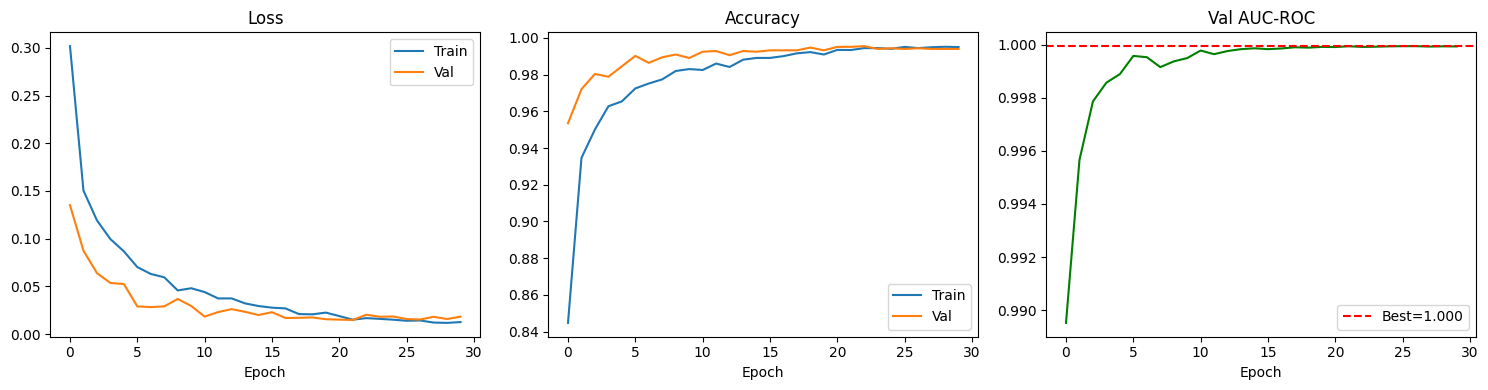

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(history['train_acc'], label='Train')
axes[1].plot(history['val_acc'], label='Val')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].set_xlabel('Epoch')

axes[2].plot(history['val_auc'], color='green')
axes[2].set_title('Val AUC-ROC'); axes[2].set_xlabel('Epoch')
axes[2].axhline(best_val_auc, ls='--', color='red', label=f'Best={best_val_auc:.3f}')
axes[2].legend()

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150)
plt.show()

## 1️⃣1️⃣ Evaluation on Test Set

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00      1719
  Dysarthric       0.99      1.00      0.99       927

    accuracy                           1.00      2646
   macro avg       0.99      1.00      1.00      2646
weighted avg       1.00      1.00      1.00      2646



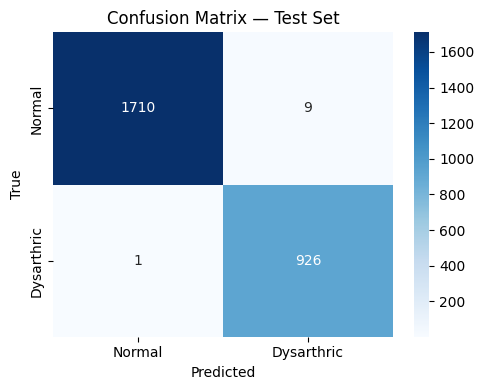

Test AUC-ROC: 0.9995


In [13]:
# Load best model
checkpoint = torch.load(MODEL_SAVE_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint['model_state'])
model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(DEVICE)
        out = model(X)
        probs = torch.softmax(out, dim=1)[:, 1]
        preds = out.argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.numpy())
        all_probs.extend(probs.cpu().numpy())

# ── Classification Report ──
print('Classification Report:')
print(classification_report(all_labels, all_preds, target_names=['Normal', 'Dysarthric']))

# ── Confusion Matrix ──
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Dysarthric'],
            yticklabels=['Normal', 'Dysarthric'])
plt.title('Confusion Matrix — Test Set')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150)
plt.show()

test_auc = roc_auc_score(all_labels, all_probs)
print(f'Test AUC-ROC: {test_auc:.4f}')

## 1️⃣2️⃣ Export Model for VS Code (inference-ready)

In [14]:
# Save full model + config for local inference
EXPORT_PATH = '/kaggle/working/voice_model_export.pt'

torch.save({
    'model_state': model.state_dict(),
    'model_class': 'EfficientNet-B0 (VoiceClassifier)',
    'labels': {0: 'Normal', 1: 'Dysarthric'},
    'sr': SR,
    'duration': DURATION,
    'n_mels': N_MELS,
    'n_fft': N_FFT,
    'hop_length': HOP_LENGTH,
    'fmax': FMAX,
    'img_size': (IMG_H, IMG_W),
    'val_auc': best_val_auc,
}, EXPORT_PATH)

print(f'✅ Model exported to: {EXPORT_PATH}')
print(f'File size: {os.path.getsize(EXPORT_PATH) / 1e6:.1f} MB')

# Also export as TorchScript for deployment
model.eval()
scripted = torch.jit.trace(model, torch.randn(1, 3, IMG_H, IMG_W).to(DEVICE))
scripted.save('/kaggle/working/voice_model_scripted.pt')
print('✅ TorchScript model saved (for Raspberry Pi deployment later)')

✅ Model exported to: /kaggle/working/voice_model_export.pt
File size: 17.6 MB
✅ TorchScript model saved (for Raspberry Pi deployment later)


---
# 🎤 VS Code — Test with Your Voice

Copy the code below into a file `test_voice.py` in VS Code.

**Requirements:**
```bash
pip install librosa sounddevice numpy torch torchvision
```


In [ ]:
VSCODE_TEST_CODE = '''
# ═══════════════════════════════════════════════════════════════
# test_voice.py — Real-time voice test with trained model
# Run: python test_voice.py
# ═══════════════════════════════════════════════════════════════

import numpy as np
import torch
import torch.nn as nn
import librosa
import sounddevice as sd
import sys
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

# ── Model definition (must match training) ──
class VoiceClassifier(nn.Module):
    def __init__(self, num_classes=2, dropout=0.4):
        super().__init__()
        base = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
        self.features = base.features
        self.avgpool = base.avgpool
        in_features = base.classifier[1].in_features
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

# ── Config (must match training) ──
SR = 16000
DURATION = 3.0
N_SAMPLES = int(SR * DURATION)
N_MELS = 128
N_FFT = 1024
HOP_LENGTH = 512
FMAX = 8000
IMG_H, IMG_W = 128, 128
LABELS = {0: '✅ Normal', 1: '⚠️  Dysarthric / Risk Detected'}
MODEL_PATH = 'voice_model_export.pt'  # adjust path

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def load_model():
    checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
    model = VoiceClassifier().to(DEVICE)
    model.load_state_dict(checkpoint['model_state'])
    model.eval()
    print(f"Model loaded — Val AUC: {checkpoint.get('val_auc', 'N/A')}")
    return model

def audio_to_melspec(y):
    mel = librosa.feature.melspectrogram(
        y=y, sr=SR, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH, fmax=FMAX
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-6)
    mel_db = np.array([
        np.interp(np.linspace(0, mel_db.shape[1]-1, IMG_W),
                  np.arange(mel_db.shape[1]), row)
        for row in mel_db
    ])
    return mel_db.astype(np.float32)

def predict_from_array(model, y):
    """Predict from raw numpy audio array."""
    if len(y) < N_SAMPLES:
        y = np.pad(y, (0, N_SAMPLES - len(y)))
    else:
        y = y[:N_SAMPLES]
    
    mel = audio_to_melspec(y)
    x = torch.tensor(mel).unsqueeze(0).repeat(3, 1, 1).unsqueeze(0).to(DEVICE)
    
    with torch.no_grad():
        out = model(x)
        probs = torch.softmax(out, dim=1)[0]
        pred = out.argmax(1).item()
    
    return pred, probs[0].item(), probs[1].item()

def record_and_predict(model, duration=DURATION):
    print(f"\n🎙️  Recording {duration}s — speak now (any language, any words)...")
    audio = sd.rec(int(duration * SR), samplerate=SR, channels=1, dtype='float32')
    sd.wait()
    y = audio.flatten()
    print("✅ Recording done. Analyzing...")
    
    pred, prob_normal, prob_dys = predict_from_array(model, y)
    
    print("\n" + "="*45)
    print(f"  RESULT: {LABELS[pred]}")
    print(f"  Confidence — Normal:     {prob_normal*100:.1f}%")
    print(f"  Confidence — Dysarthric: {prob_dys*100:.1f}%")
    print("="*45)
    
    # Risk level for your fainting detection pipeline
    if prob_dys > 0.7:
        print("  🚨 HIGH RISK — Escalate to emergency system")
    elif prob_dys > 0.4:
        print("  ⚠️  MODERATE RISK — Trigger confirmation dialogue")
    else:
        print("  ✅ LOW RISK — Continue monitoring")
    
    return pred, prob_dys

def predict_from_file(model, path):
    """Predict from an existing audio file."""
    y, _ = librosa.load(path, sr=SR, mono=True)
    pred, prob_normal, prob_dys = predict_from_array(model, y)
    print(f"File: {path}")
    print(f"Result: {LABELS[pred]} | Normal: {prob_normal:.3f} | Dysarthric: {prob_dys:.3f}")
    return pred, prob_dys

# ── Main ──
if __name__ == "__main__":
    model = load_model()
    
    # Mode: realtime or file
    if len(sys.argv) > 1:
        # python test_voice.py path/to/audio.wav
        predict_from_file(model, sys.argv[1])
    else:
        # Interactive loop: press Enter to record, Ctrl+C to stop
        print("\n🎤 Real-time Voice Risk Detector")
        print("Speak any language — model is language agnostic")
        print("Press Enter to record | Ctrl+C to exit\n")
        
        while True:
            try:
                input("Press Enter to start recording...")
                record_and_predict(model)
            except KeyboardInterrupt:
                print("\nExiting. Goodbye!")
                break
'''

# Save to a Python file so you can download it
with open('/kaggle/working/test_voice.py', 'w') as f:
    f.write(VSCODE_TEST_CODE)

print('✅ test_voice.py saved to /kaggle/working/')
print('Download it along with voice_model_export.pt')

## 1️⃣3️⃣ Files to Download

In [ ]:
import os
files = [
    '/kaggle/working/voice_model_export.pt',
    '/kaggle/working/voice_model_scripted.pt',
    '/kaggle/working/test_voice.py',
    '/kaggle/working/training_curves.png',
    '/kaggle/working/confusion_matrix.png',
]
print('📦 Files to download from Kaggle output:')
for f in files:
    if os.path.exists(f):
        size = os.path.getsize(f) / 1e6
        print(f'  ✅ {f.split("/")[-1]:35s} {size:.1f} MB')
    else:
        print(f'  ❌ {f} — not found')

print()
print('📋 Instructions:')
print('1. Download voice_model_export.pt and test_voice.py')
print('2. Put both in same folder in VS Code')
print('3. pip install librosa sounddevice torch torchvision')
print('4. python test_voice.py             ← realtime mic')
print('5. python test_voice.py audio.wav   ← from file')